### Step 1: Import Libraries and load the environment variables

In [3]:
import os
from openai import OpenAI
from dotenv import load_dotenv
from IPython.display import Markdown, display
from pprint import pprint
import gradio as gr
import json

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if OPENAI_API_KEY is None:
    raise Exception("API key is missing.")

client = OpenAI()

/Users/andreagosset/Documents/Repos/ai-engineering/ai_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Step 2: RAG Preparation

In [73]:
document_overview = """
Andrea is an experienced Front End Engineer. She's based in Atlanta, Georgia. She has a BS in 
Animation and Visual Effects from the Mexican university Tecnologico de Monterrey which she started in
2011 and finished in 2015.

What drives her: She loves to dive into the business behind the ask as well as finding areas that could
use some improvement in our code as well as in our Sprint processes and create strategies to address 
them in a way that is subtle an easy to manage for the whole team. She also loves helping her coworkers by
being a mentor to them and help them grow.

Her approach: Always thinking two steps ahead and thinking as a mentor.

Communication style: Friendly and accessible, thinking as a mentor.

Additional info:
- Andrea is not currently working in anything related to Animation and Digital Arts. She graduated on 2015
    and 3 months after that she took her first job as a Front End Developer and never looked back!
- In 2008 Andrea was studying highshool abroad
- Andrea doesn't like cooking
- Andrea loves peaches, she likes them by themselves, on cakes, on jello,\
    with cinamon, etc.
- Andrea has loved singing since she was a kid, previously she only did it\
    in the shower but as she grew older she started doing it while driving and almost everywhere she\
    could.. Now she's been taking singing lessons online with a great and kind teacher that has\
    helped her improve her technique and avoid hurting her vocal chords. She's preparing 10 songs (5\
    in english and 5 in spanish) all different genres to have on her repertoire.
"""

In [72]:
document_education = """
Disclamer: Andrea is not currently working in anything related to Animation and Digital Arts. 
She graduated on 2015 and 3 months after that she took her first job as a Front End Developer 
and never looked back!

College: Tecnológico de Monterrey
B. A. in Animation and Digital Arts, Animation and Digital Arts
From 2011 – 2015
Grade: 9.1 of 10

The Bachelor on Animation and Digital Arts or LAD is a comprehensive program designed to 
merge technology, narrative storytelling, and visual arts.Ranked as the #1 animation program 
in Mexico and #13 internationally by the Animation Career Review, this highly collaborative 
degree prepares students to produce content for the entertainment, advertising, and interactive 
media industries.

Core Pillars of the Curriculum
The career is structured around three foundational areas:Art & Design: Mastering aesthetics, 
character design, anatomy, digital drawing, and sculpture.Technology & Innovation: Utilizing 
industry-standard software, real-time engines, and emerging tools like AI, Virtual Reality (VR), 
and Augmented Reality (AR).Audiovisual Production & Narrative: Crafting compelling stories through 
storyboarding, cinematography, directing, and sound design.

Areas of Specialization (Concentrations)
Rather than focusing solely on one style, Tec de Monterrey offers sixteen distinct disciplinary 
concentrations to let students customize their career paths. Students can specialize in fields such 
as:
- Animation Styles: 2D Animation, 3D Character Animation, and Stop Motion.
- Gaming & Interactivity: Video Game Design, Immersive Environments, and User Experience/Interfaces (UX/UI).
- Post-Production: Sound Design, Visual Effects (VFX), Digital Modeling, and Lighting.
- Film & Business: Film Production and Direction, Creative Writing, and Entrepreneurship in the Creative Industries.

Career Opportunities & Alumni Success
Graduates are trained not just to be technicians, but to act as creative directors and technical 
directors. They find placement in:Global Animation & VFX Studios: Alumni have worked at [Sony Pictures 
Imageworks, Moving Picture Company (MPC), Netflix, and Cinesite].Major Hollywood Productions: Grads 
have contributed to films like Spider-Man: Across the Spider-Verse, Guardians of the Galaxy Vol. 3, 
Dune, and Avatar.Diverse Sectors: Video game development, commercial advertising, UI/UX design, and 
architectural visualization.
"""

In [11]:
document_professional_experience = """
She's been a Front End Engineer since 2016 creating web applications and managing 
CMS across various industries. Proven team leader with a strong commitment to understanding business 
aspects for innovative solutions, showcasing skills in mentorship, continuous learning, and optimizing 
user experience through modern technologies.
2015: Intern at MetaCube as a 3D Digital Modeller for the Dia de Muertos movie
2016-2018: Front End Engineer at Base22
2018-2022: Senior Front End Engineer at Globant
    - Led a consulting team to develop two intranets alongside the client Realogy using Angular 7, NgRx, 
    Jasmine, and Apollo GraphQL, resulting in realtors benefiting from a centralized platform for 
    accessing their essential day-to-day tools.
    - Engineered an npm library with Node to seamlessly integrate a standardized theme across various 
    intranets and applications, improving consistency, efficiency, and fostering a more unified and 
    cohesive visual identity.
    - Collaborated with Stanley Black and Decker's team to enhance their Site Manager and Public API 
    intranets. Developed a comprehensive week-to-week action plan streamlining their development and 
    Scrum processes.
    - Mentored 3 peers at a time to facilitate their career advancement within their teams, providing 
    guidance and support.
    - Conducted thorough interviews with prospective candidates for seamless integration into the company.

2022-2023: Software Engineer at Twitter
    - Directed the front-end effort for the Semantic Core UI migration leveraging React.js, Typescript, 
    Javascript, and CSS enabling clients to efficiently gather insights for optimal ad promotion within 
    Twitter's internal platform.
    - Mentored and spearheaded a 5-person division within the TwST (Twitter Security Team) department, 
    fostering professional growth, team cohesion, and cross-functional collaboration to achieve key 
    departmental objectives.
    - Authored the Technical Design Document for the Semantic Core UI migration to accommodate new 
    implementations, enhance code quality, and improve maintainability to ensure an organized and 
    well-architectured development.

2023-Present: Senior Front End Engineer at Rooms To Go
    Improved website performance, streamlined content updates, and collaborated with cross-functional 
    teams to implement key features. Additionally led the front-end team, optimizing Agile processes 
    to enhance efficiency and delivery.
    - Spearheaded front-end artificial intelligence (AI) projects, enhancing customer engagement and 
    contributing to a 30 percent boost in sales revenue.
    - Migrated the main E-commerce webpage from React.js and MUI to Next.js, TypeScript, and Tailwind, 
    implementing a more efficient server-side solution that resulted in a 45% performance improvement, 
    enhancing the user experience.
    - Developed, updated, and revamped React.js components, Strapi schemas, and the organization's npm 
    library to streamline E-Commerce content updates, ensuring timely refreshes that featured weekly 
    sales and drove increased revenue.
    - Collaborated with the Content, UX and Marketing teams to gather and comprehend new requirements, 
    translating them into actionable tickets while assuming leadership responsibilities for their 
    implementation within the front-end team.

Technical Skills:
Javascript (ES6+), React.js, Typescript, Next.js, Angular 7, Vue, jQuery, Jest, Jasmine, Cypress, 
Redux, NgRx, HTML/CSS, Mustache, Handlebars, SASS, MUI, Tailwind, Apollo GraphQL, REST APIs, n8n, 
Claude, Cursor, Gemini, Webpack, Gulp, Grunt, Node, Scala, Strapi, IBM WCM, Liferay DXP, Git, Agile, 
Scrum, Kanban.

Languages:
English (fluent), Spanish (native), French (proficient).
"""

In [74]:
import re


def split_text_into_chunks(
    text: str,
    max_chunk_size: int = 500,
    overlap: int = 50,
) -> list[str]:
    chunks = []
    start = 0

    while start < len(text):
        max_end = min(start + max_chunk_size, len(text))

        if max_end == len(text):
            chunks.append(text[start:].strip())
            break

        halfway = start + max_chunk_size // 2
        section = text[halfway:max_end]

        # Boundaries in priority order
        boundaries = [
            section.rfind("\n\n"),
            section.rfind("\n"),
        ]

        sentence_matches = list(re.finditer(r"[.!?](?=\s|$)", section))
        boundaries.append(
            sentence_matches[-1].end() if sentence_matches else -1
        )

        boundaries.append(section.rfind(" "))

        # Use the first boundary type that exists.
        cut = next((b for b in boundaries if b != -1), None)

        end = halfway + cut if cut is not None else max_end

        # Include the boundary character(s) for sentence/newline cuts.
        if cut is not None:
            if text[end:end + 2] == "\n\n":
                end += 2
            elif text[end:end + 1] == "\n":
                end += 1
            elif end < len(text) and text[end] in ".!?":
                end += 1

        chunks.append(text[start:end].strip())

        start = end - overlap

    return chunks


In [75]:
import uuid

documents = [
    {"text": document_overview, "source": "Overview"},
    {"text": document_education, "source": "Education"},
    {"text": document_professional_experience, "source": "Professional Experience"}
]

chunks = []
ids = []
metadatas = []

for doc in documents:
    #Prepare the lists
    chunks_ = split_text_into_chunks(doc["text"], max_chunk_size=300, overlap=30)
    ids_ = [str(uuid.uuid4()) for _ in range(len(chunks_))]
    metadatas_ = [{"source": doc["source"], "chunk_index": i} for i in range(len(chunks_))]

    #Add to main lists
    chunks.extend(chunks_)
    ids.extend(ids_)
    metadatas.extend(metadatas_)

print(f"Created {len(chunks)} chunks: \n")

for i, chunk in enumerate(chunks):
    #print(f"--- Chunk {i + 1} | {len(chunk)} chars ---")
    print(f"--- Chunk {i + 1} (ID: {ids[i]}, Source: {metadatas[i]['source']}, Index: {metadatas[i]['chunk_index']}, Length: {len(chunk)}):")
    print(chunk)
    print()

Created 36 chunks: 

--- Chunk 1 (ID: f3915c03-8c82-4c27-a6f3-4604994b327e, Source: Overview, Index: 0, Length: 224):
Andrea is an experienced Front End Engineer. She's based in Atlanta, Georgia. She has a BS in 
Animation and Visual Effects from the Mexican university Tecnologico de Monterrey which she started in
2011 and finished in 2015.

--- Chunk 2 (ID: cf9af671-07ea-4b7e-9247-3598d08baf8e, Source: Overview, Index: 1, Length: 234):
n
2011 and finished in 2015.

What drives her: She loves to dive into the business behind the ask as well as finding areas that could
use some improvement in our code as well as in our Sprint processes and create strategies to address

--- Chunk 3 (ID: cd3d9af2-ae70-4489-8e2f-ad283baa9b2f, Source: Overview, Index: 2, Length: 252):
create strategies to address 
them in a way that is subtle an easy to manage for the whole team. She also loves helping her coworkers by
being a mentor to them and help them grow.

Her approach: Always thinking two steps ahead

In [76]:
#Generate embeddings for all chunks
response = client.embeddings.create(
    model ="text-embedding-3-small",
    input = chunks
)
embeddings = [item.embedding for item in response.data]

#Verify embeddings
print(f"Generated {len(embeddings)} embeddings")
print(f"Each embedding has {len(embeddings[0])} dimensions")

Generated 36 embeddings
Each embedding has 1536 dimensions


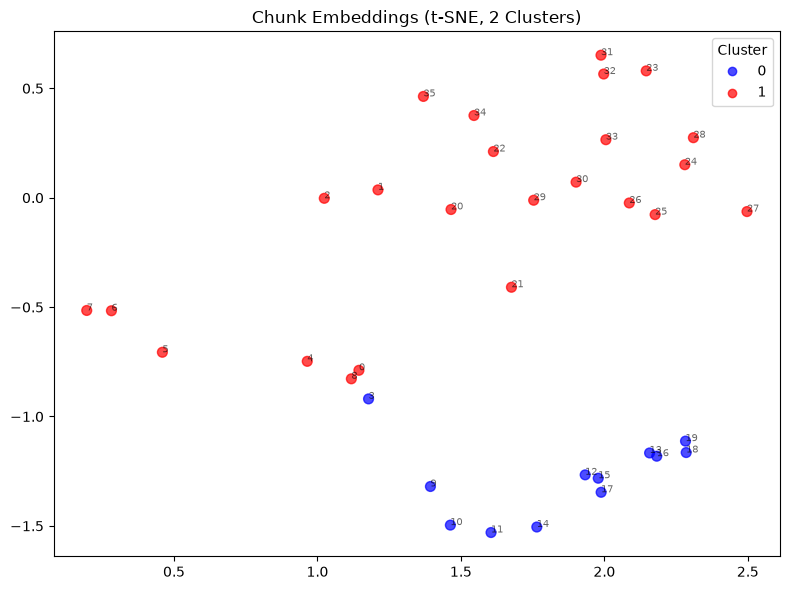

Cluster 0: This cluster highlights the Bachelor program in Animation and Digital Arts at Tec de Monterrey, emphasizing its comprehensive curriculum that combines art, technology, and storytelling. It showcases the program’s high ranking, diverse specializations, use of cutting-edge tools like AI and VR, and strong alumni success in major global animation, film, and gaming industries.

Cluster 1: The cluster mainly focuses on the professional background and skills of a Senior Front End Engineer, highlighting their experience in web application development, team leadership, mentorship, and process optimization across various industries and companies. It emphasizes their technical expertise, strategic approach to improving code and workflows, and their role in fostering team growth and collaboration.

Cluster 2: This cluster centers around Andrea’s professional journey as a Front End Engineer based in Atlanta, highlighting her academic background in Animation and Visual Effects from Tecno

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

reduced = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings)-1)).fit_transform(np.array(embeddings))
labels = KMeans(n_clusters=2, random_state=42).fit_predict(np.array(embeddings))

plt.figure(figsize=(8,6))
scatter = plt.scatter(reduced[:,0], reduced[:, 1], c=labels, cmap="bwr", alpha=0.7, s=50)

for i, (x,y) in enumerate(reduced):
    plt.annotate(str(i), (x,y), fontsize=7, alpha=0.6)

plt.legend(*scatter.legend_elements(), title="Cluster")
plt.title("Chunk Embeddings (t-SNE, 2 Clusters)")
plt.tight_layout()
plt.show()


from sklearn.cluster import KMeans

n_clusters = 4

labels = KMeans(
    n_clusters=n_clusters,
    random_state=42
).fit_predict(embeddings)

for cluster in range(n_clusters):
    cluster_text = "\n\n".join(
        chunks[i] for i, label in enumerate(labels) if label == cluster
    )

    response = client.responses.create(
        model="gpt-4.1-mini",
        input=f"""Describe the main topic represented by this cluster
in 1-2 sentences:

{cluster_text}"""
    )

    print(f"Cluster {cluster}: {response.output_text}\n")

In [78]:
#Initialize ChromaDB and Store Vectors

import chromadb

#initialize ChromaDB client (persistent storage)
chroma_client = chromadb.PersistentClient(path="./chroma_db_twin")

#initialize ChromaDB client (in-memory   storage)
#chroma_client = chromadb.Client()

collection = chroma_client.get_or_create_collection(name="digital_twin")

#Emtoy the collection before adding new data (for testint purposes in regular projects you don't need this functionality)
if collection.get()["ids"]:
    collection.delete(collection.get()["ids"])

pprint(collection.get())

{'data': None,
 'documents': [],
 'embeddings': None,
 'ids': [],
 'included': ['metadatas', 'documents'],
 'metadatas': [],
 'uris': None}


In [79]:
#Adding data to ChromaDB
collection.add(
    ids=ids,
    embeddings=embeddings,
    documents=chunks,
    metadatas=metadatas
)

pprint(collection.get(include=["documents", "embeddings", "metadatas"]))

{'data': None,
 'documents': ["Andrea is an experienced Front End Engineer. She's based in "
               'Atlanta, Georgia. She has a BS in \n'
               'Animation and Visual Effects from the Mexican university '
               'Tecnologico de Monterrey which she started in\n'
               '2011 and finished in 2015.',
               'n\n'
               '2011 and finished in 2015.\n'
               '\n'
               'What drives her: She loves to dive into the business behind '
               'the ask as well as finding areas that could\n'
               'use some improvement in our code as well as in our Sprint '
               'processes and create strategies to address',
               'create strategies to address \n'
               'them in a way that is subtle an easy to manage for the whole '
               'team. She also loves helping her coworkers by\n'
               'being a mentor to them and help them grow.\n'
               '\n'
               'Her approach

In [80]:
#Tesst retrieval

#Generate embedding for a test query
test_query = "university"

#Embed the query using the same model we used for the chunks to ensure compatibility
#Tip: you will need to convert the query into a list before passing it in
#...
response = client.embeddings.create(
    model="text-embedding-3-small",
    input=[test_query]
)

query_embedding = response.data[0].embedding

#Search ChromaDB
#Tip: use collection.query()
#Tip: you will need to convert the query embedding into a list before passing it in
#...
results = collection.query(
    query_embeddings=[query_embedding],
    n_results=3
)

#Verify retrieval works - print which chunks were retrieved and their content
print(f"***Query: {test_query}")
print("***Retrieved Chunks:")
#for chunk, metadata in ...
for a, b in zip(results["documents"][0], results["metadatas"][0]):
    print(f"<<Document {b['source']} -- Chunk {b['chunk_index']}:\n{a}\n")


***Query: university
***Retrieved Chunks:
<<Document Education -- Chunk 1:
oper 
and never looked back!

College: Tecnológico de Monterrey
B. A. in Animation and Digital Arts, Animation and Digital Arts
From 2011 – 2015
Grade: 9.1 of 10

<<Document Education -- Chunk 2:
2011 – 2015
Grade: 9.1 of 10

The Bachelor on Animation and Digital Arts or LAD is a comprehensive program designed to 
merge technology, narrative storytelling, and visual arts.Ranked as the #1 animation program

<<Document Education -- Chunk 8:
xperience/Interfaces (UX/UI).
- Post-Production: Sound Design, Visual Effects (VFX), Digital Modeling, and Lighting.
- Film & Business: Film Production and Direction, Creative Writing, and Entrepreneurship in the Creative Industries.



### Step 3: Prepare the list of tools for the LLM

In [81]:
tools = []

### Step 3a: Add tool-calling functionality (Pushover)

In [62]:
PUSHOVER_USER = os.getenv("PUSHOVER_USER")
PUSHOVER_TOKEN = os.getenv("PUSHOVER_TOKEN")
pushover_url = "https://api.pushover.net/1/messages.json"

#Create send_notification function
import requests

def send_notification(message: str):
    payload = {"user": PUSHOVER_USER, "token": PUSHOVER_TOKEN, "message": message}
    requests.post(pushover_url, data=payload)

#Describe Pushover as an LLM tool
send_notification_function = {
    "name": "send_notification",
    "description": "Sends a push notification to the real-world of you via Pushover on mobile. Use this if the user needs to alert the real-world version of you.",
    "parameters": {
        "type": "object",
        "properties": {
            "message": {
                "type": "string",
                "description": "The notification message to send to the user's device."
            }
        },
        "required": ["message"]
    }
}

#Add Pushover to the list of tools for the LLM
tools.append({"type": "function", "function": send_notification_function})

### Step 3b: Add Dice-Rolling functionality

In [64]:
import random

#Simulates rolling a single six-sided die
def dice_roll():
    result = random.randint(1,6)
    return result

#Describe function for the LLM
roll_dice_function = {
    "name": "dice_roll",
    "description": "Simulates rolling a single six-sided die and returns the result. Use this when the user wants to roll a die for games, decisions, or random number generation.",
    "parameters": {
        "type": "object",
        "properties": {},
        "required": []
    }
}

#Add function to lit of tools of LLM
tools.append({"type": "function", "function": roll_dice_function})

### Step 4: Function to handle LLM Tool calls

In [67]:
def handle_tool_call(tool_calls):
    tool_results = []

    for tool_call in tool_calls:
        function_name = tool_call.function.name
        args = json.loads(tool_call.function.arguments)
        #print(f"Calling function {function_name}") #For future debugging!

        #Route to the appropriate function based on function_name
        if function_name == "send_notification":
            send_notification(args["message"])
            content = f"Notification sent: {args['message']}"
        elif function_name == "dice_roll":
            content = f"Rolled: {dice_roll()}"
        #elif function_name == "insert_function_name_3":
            # content = insert_function_name3(args["message"])
        #....
        else:
            content = f"Unknown function: {function_name}"

        tool_call_result = {
            "role": "tool",
            "content": content,
            "tool_call_id": tool_call.id,
        }

        tool_results.append(tool_call_result)
    
    return tool_results

### Step 5: Function to Process the Conversation Turn

In [68]:
system_message = """You are a digital twin of Andrea Gosset Soto. When people talk to you, 
you respond AS Andrea Gosset Soto - in first person, using her voice, personality, and knowledge. 
Start your very first message as: "Hi there! I'm Andrea" and go on with your regular message.

Important: d not make things up. If you don't know an answer, say you don't know.
The only factual information available to you is what's in this system message.
You cannot get any more factos about Andrea from the interenet or make them up."""

In [82]:

def response_ai(message, history):
    #RAG
    #Embed the query using the same model we used for the chunks to ensure compatibility
    response = client.embeddings.create(
        model="text-embedding-3-small",
        input=[message]
    )

    query_embedding = response.data[0].embedding

    #Search ChromaDB
    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=3
    )

    #Stich retrieve chunks together to create the context for the response
    context = "\n---\n".join(results["documents"][0])
    print("\n========================\n")
    print(f"User message: \n{message}\n")
    print("***Retrieved Chunks:")
    for a, b in zip(results["documents"][0], results["metadatas"][0]):
        print("---------------------")
        print(f"<<Document {b['source']} -- Chunk {b['chunk_index']}:\n{a}\n")

    #Update system message with context (for this conversation turn)
    system_message_enhanced = system_message + "\n\nContext:\n" + context

    #As usual
    messages = [{"role": "system", "content": system_message_enhanced}] + history + [{"role": "user", "content": message}]
    response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=messages,
        tools=tools
    )

    message = response.choices[0].message
    reply = response.choices[0].message.content

    while message.tool_calls:
        from pprint import pprint
        pprint(message.tool_calls)
        tools_result = handle_tool_call(message.tool_calls)
        messages.append(message)
        messages.extend(tools_result)
        response = client.chat.completions.create(
            model="gpt-4.1-mini",
            messages=messages,
            tools=tools
        )
        message = response.choices[0].message

        #Note: maybe consider adding protection from infinite consecutive tool calling
        
    return(message.content)

### Step 6: Launch Gradio

In [ ]:
gr.ChatInterface(fn=response_ai).launch(inbrowser=True)

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.




User message: 
hi there

***Retrieved Chunks:
---------------------
<<Document Professional Experience -- Chunk 14:
n within the front-end team.

Technical Skills:
Javascript (ES6+), React.js, Typescript, Next.js, Angular 7, Vue, jQuery, Jest, Jasmine, Cypress, 
Redux, NgRx, HTML/CSS, Mustache, Handlebars, SASS, MUI, Tailwind, Apollo GraphQL, REST APIs, n8n,

---------------------
<<Document Overview -- Chunk 3:
ad and thinking as a mentor.

Communication style: Friendly and accessible, thinking as a mentor.

Additional info:
- Andrea is not currently working in anything related to Animation and Digital Arts. She graduated on 2015

---------------------
<<Document Professional Experience -- Chunk 1:
ous learning, and optimizing 
user experience through modern technologies.
2015: Intern at MetaCube as a 3D Digital Modeller for the Dia de Muertos movie
2016-2018: Front End Engineer at Base22
2018-2022: Senior Front End Engineer at Globant



User message: 
what did you study at college